|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>The EMNIST dataset (letter recognition)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
import copy
from sklearn.model_selection import train_test_split


# for importing data
import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Import and inspect the data

In [3]:
# download the dataset
letters_cdata = torchvision.datasets.EMNIST(root='../sample_data/emnist',split='letters',download=True)
digits_cdata = torchvision.datasets.EMNIST(root='../sample_data/emnist',split='digits',download=True)

# more info: https://www.nist.gov/itl/products-and-services/emnist-dataset

In [4]:
# inspect the letters data

# the categories (but how many letters??)
print(letters_cdata.classes)
print(str(len(letters_cdata.classes)) + ' classes')

print('\nData size:')
print(letters_cdata.data.shape)
# transform to 4D tensor for conv layers (and transform from int8 to float)
letters_images = letters_cdata.data.view([-1,1,28,28]).float()
print('\nTensor data:')
print(letters_images.shape)

['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# inspect the digits data

# the categories (but how many letters??)
print(digits_cdata.classes)
print(str(len(digits_cdata.classes)) + ' classes')

print('\nData size:')
print(digits_cdata.data.shape)
# transform to 4D tensor for conv layers (and transform from int8 to float)
digits_images = digits_cdata.data.view([-1,1,28,28]).float()
print('\nTensor data:')
print(digits_images.shape)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
10 classes

Data size:
torch.Size([240000, 28, 28])

Tensor data:
torch.Size([240000, 1, 28, 28])


In [6]:
# brief aside: class 'N/A' doesn't exist in the data.
print( torch.sum(letters_cdata.targets==0) )
print( torch.sum(digits_cdata.targets==0) )

# However, it causes problems in one-hot encoding...
print(torch.unique(letters_cdata.targets))
print(torch.unique(digits_cdata.targets))

tensor(0)
tensor(24000)
tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


In [7]:
print(letters_cdata.class_to_idx)
print(digits_cdata.class_to_idx)

{'N/A': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}


In [8]:
# so therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letterCategories = letters_cdata.classes[1:]
digitCategories = digits_cdata.classes

# relabel labels to start at 0
letters_labels = copy.deepcopy(letters_cdata.targets)-1
digits_labels = copy.deepcopy(digits_cdata.targets)
print(letters_labels.shape)
print(digits_labels.shape)

###
print( torch.sum(letters_labels==0) )
print(torch.unique(letters_labels))

print( torch.sum(letters_labels==0) )
print(torch.unique(letters_labels))

print( torch.sum(digits_labels==0) )
print(torch.unique(digits_labels))

torch.Size([124800])
torch.Size([240000])
tensor(4800)
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])
tensor(4800)
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])
tensor(24000)
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


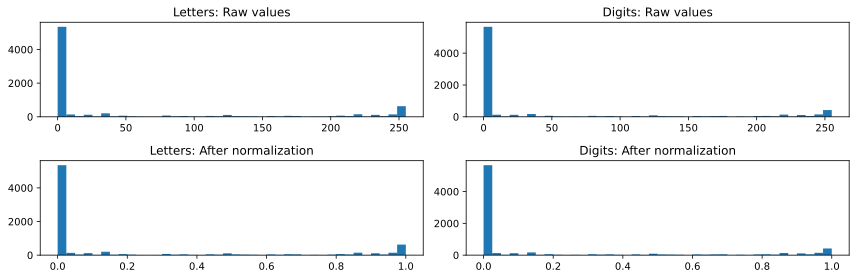

In [9]:
# next issue: do we need to normalize the images?
fig, axs = plt.subplots(2,2,figsize=(12,4))
axs[0,0].hist(letters_images[:10,:,:,:].flatten().detach(),40)
axs[0,0].set_title('Letters: Raw values')

axs[0,1].hist(digits_images[:10,:,:,:].flatten().detach(),40)
axs[0,1].set_title('Digits: Raw values')

# yarp.
letters_images /= torch.max(letters_images)
digits_images /= torch.max(digits_images)

axs[1,0].hist(letters_images[:10,:,:,:].flatten().detach(),40)
axs[1,0].set_title('Letters: After normalization')

axs[1,1].hist(digits_images[:10,:,:,:].flatten().detach(),40)
axs[1,1].set_title('Digits: After normalization')

fig.tight_layout()
plt.show()

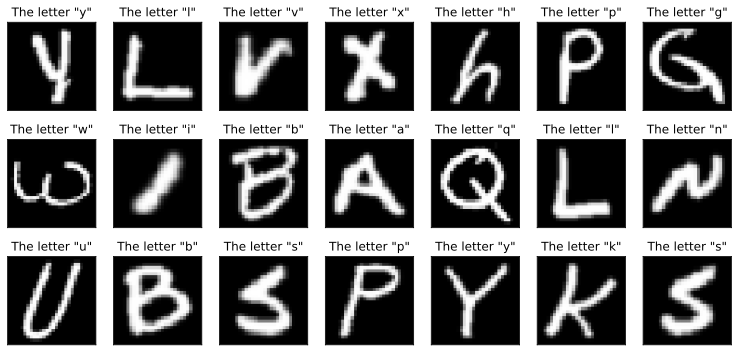

In [10]:
# visualize some images from letters
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):

  # pick a random pic
  whichpic = np.random.randint(letters_images.shape[0])

  # extract the image and its target letter
  I = np.squeeze( letters_images[whichpic,:,:] )
  letter = letterCategories[letters_labels[whichpic]]

  # visualize
  ax.imshow(I.T,cmap='gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

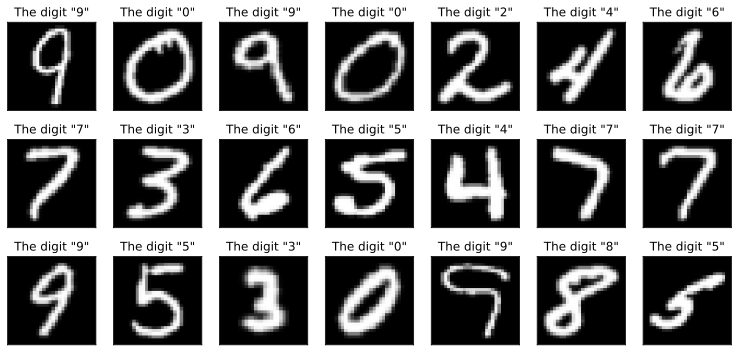

In [11]:
# visualize some images from digits
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):

  # pick a random pic
  whichpic = np.random.randint(digits_images.shape[0])

  # extract the image and its target digit
  I = np.squeeze( digits_images[whichpic] )
  digit = digitCategories[digits_labels[whichpic]]
  # visualize
  ax.imshow(I.T,cmap='gray')
  ax.set_title('The digit "%s"'%digit)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create train/test groups using DataLoader

In [12]:
# Step 2: use scikitlearn to split the data
letters_train_data,letters_test_data, letters_train_labels,letters_test_labels = train_test_split(letters_images, letters_labels, test_size=.1)
digits_train_data,digits_test_data, digits_train_labels,digits_test_labels = train_test_split(digits_images, digits_labels, test_size=.1)
    
# Step 3: convert into PyTorch Datasets
letters_train_data = TensorDataset(letters_train_data,letters_train_labels)
letters_test_data  = TensorDataset(letters_test_data,letters_test_labels)

digits_train_data = TensorDataset(digits_train_data,digits_train_labels)
digits_test_data  = TensorDataset(digits_test_data,digits_test_labels)

# Step 4: translate into dataloader objects
batchsize    = 125
letters_train_loader = DataLoader(letters_train_data,batch_size=batchsize,shuffle=True,drop_last=True)
letters_test_loader  = DataLoader(letters_test_data,batch_size=letters_test_data.tensors[0].shape[0])

digits_train_loader = DataLoader(digits_train_data,batch_size=batchsize,shuffle=True,drop_last=True)
digits_test_loader  = DataLoader(digits_test_data,batch_size=digits_test_data.tensors[0].shape[0])

In [13]:
# check size (should be images X channels X width X height
print( letters_train_loader.dataset.tensors[0].shape )
print( letters_train_loader.dataset.tensors[1].shape )

print( letters_test_loader.dataset.tensors[0].shape )
print( letters_test_loader.dataset.tensors[1].shape )

print( digits_train_loader.dataset.tensors[0].shape )
print( digits_train_loader.dataset.tensors[1].shape )

print( digits_test_loader.dataset.tensors[0].shape )
print( digits_test_loader.dataset.tensors[1].shape )

torch.Size([112320, 1, 28, 28])
torch.Size([112320])
torch.Size([12480, 1, 28, 28])
torch.Size([12480])
torch.Size([216000, 1, 28, 28])
torch.Size([216000])
torch.Size([24000, 1, 28, 28])
torch.Size([24000])


# Create the DL model

In [14]:
# create a class for the model
def makeTheNet(nOutputs:int=26,printtoggle:bool=False):

  class emnistnet(nn.Module):
    def __init__(self,printtoggle,nOutputs:int=26):
      super().__init__()

      # print toggle
      self.print = printtoggle

      ### -------------- feature map layers -------------- ###
      # first convolution layer
      self.conv1  = nn.Conv2d(1,6,3,padding=1)
      self.bnorm1 = nn.BatchNorm2d(6) # input the number of channels in this layer
      # output size: (28+2*1-3)/1 + 1 = 28/2 = 14 (/2 b/c maxpool)

      # second convolution layer
      self.conv2  = nn.Conv2d(6,6,3,padding=1)
      self.bnorm2 = nn.BatchNorm2d(6) # input the number of channels in this layer
      # output size: (14+2*1-3)/1 + 1 = 14/2 = 7 (/2 b/c maxpool)


      ### -------------- linear decision layers -------------- ###
      self.fc1 = nn.Linear(7*7*6,50)
      self.fc2 = nn.Linear(50,nOutputs)

    def forward(self,x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv1(x),2)
      x = F.leaky_relu(self.bnorm1(x))
      if self.print: print(f'First CPR block: {list(x.shape)}')

      # second block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv2(x),2)
      x = F.leaky_relu(self.bnorm2(x))
      if self.print: print(f'Second CPR block: {list(x.shape)}')

      # reshape for linear layer
      nUnits = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(nUnits))
      if self.print: print(f'Vectorized: {list(x.shape)}')

      # linear layers
      x = F.leaky_relu(self.fc1(x))
      x = self.fc2(x)
      if self.print: print(f'Final output: {list(x.shape)}')

      return x

    def set_conv_layers_freeze(self, freeze:bool=True):
      for i,layer in enumerate(['conv1','bnorm1','conv2','bnorm2']):
        params = getattr(self,layer).parameters()
        w,b = iter(params)
        w.requires_grad_(not freeze)
        b.requires_grad_(not freeze)
        
    def set_flat_layers_freeze(self, freeze:bool=True):
      for i,layer in enumerate(['fc1','fc2']):
        params = getattr(self,layer).parameters()
        w,b = iter(params)
        w.requires_grad_(not freeze)
        b.requires_grad_(not freeze)
        
    def conv_layers_status_str(self) -> str:
      str_statur:str = ''
      for i,layer in enumerate(['conv1','bnorm1','conv2','bnorm2','fc1','fc2']):
        params = getattr(self,layer).parameters()
        w,b = iter(params)
        str_statur += f'Layer {i+1} ({layer}): weights require_grad={w.requires_grad}, bias requires_grad={b.requires_grad}\n'
      return str_statur
    
    @staticmethod
    def accuracy(yHat:torch.Tensor,y:torch.Tensor) -> float:
      return torch.mean((torch.argmax(yHat,axis=1) == y).float()).item()
    
    @staticmethod
    def error(yHat:torch.Tensor,y:torch.Tensor) -> float:
      return 1.0 - emnistnet.accuracy(yHat,y)

  # create the model instance
  net = emnistnet(nOutputs=nOutputs,printtoggle=printtoggle)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [15]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet(printtoggle=True)

print('\n',net.conv_layers_status_str())
net.set_conv_layers_freeze(freeze=True)
print('\n',net.conv_layers_status_str())
net.set_flat_layers_freeze(freeze=True)
print('\n',net.conv_layers_status_str())

X,y = next(iter(letters_train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:', yHat.shape)

# # now let's compute the loss
print('\nLoss:', lossfun(yHat,torch.squeeze(y)))
print('Accuracy:', net.accuracy(yHat,torch.squeeze(y)))
print('Error:', net.error(yHat,torch.squeeze(y)))


 Layer 1 (conv1): weights require_grad=True, bias requires_grad=True
Layer 2 (bnorm1): weights require_grad=True, bias requires_grad=True
Layer 3 (conv2): weights require_grad=True, bias requires_grad=True
Layer 4 (bnorm2): weights require_grad=True, bias requires_grad=True
Layer 5 (fc1): weights require_grad=True, bias requires_grad=True
Layer 6 (fc2): weights require_grad=True, bias requires_grad=True


 Layer 1 (conv1): weights require_grad=False, bias requires_grad=False
Layer 2 (bnorm1): weights require_grad=False, bias requires_grad=False
Layer 3 (conv2): weights require_grad=False, bias requires_grad=False
Layer 4 (bnorm2): weights require_grad=False, bias requires_grad=False
Layer 5 (fc1): weights require_grad=True, bias requires_grad=True
Layer 6 (fc2): weights require_grad=True, bias requires_grad=True


 Layer 1 (conv1): weights require_grad=False, bias requires_grad=False
Layer 2 (bnorm1): weights require_grad=False, bias requires_grad=False
Layer 3 (conv2): weights requir

# Create a function that trains the model

In [16]:
# a function that trains the model

def function2trainTheModel(net,lossfun,optimizer,
    train_loader:torch.utils.data.DataLoader, test_loader:torch.utils.data.DataLoader, numepochs:int=10):

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainErr  = torch.zeros(numepochs)
  testErr   = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    net.train()
    batchLoss = []
    batchErr  = []
    for X,y in train_loader:

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchErr.append( net.error(yHat,y) )
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainErr[epochi]  = 100*np.mean(batchErr)

    ### test performance
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader

    # push data to GPU
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)

    # get loss and error rate from the test batch
    testLoss[epochi] = loss.item()
    testErr[epochi]  = 100*net.error(yHat,y)

  # end epochs

  # function output
  return trainLoss,testLoss,trainErr,testErr,net

# Run the model and show the results!

In [17]:
# ~2 minutes with 10 epochs on GPU (8 mins on the CPU!)
letters_net,letters_lossfun,letters_optimizer = makeTheNet()
letters_trainLoss,letters_testLoss,letters_trainErr,letters_testErr,letters_net = \
    function2trainTheModel(letters_net,letters_lossfun,letters_optimizer,letters_train_loader,letters_test_loader,numepochs=5)

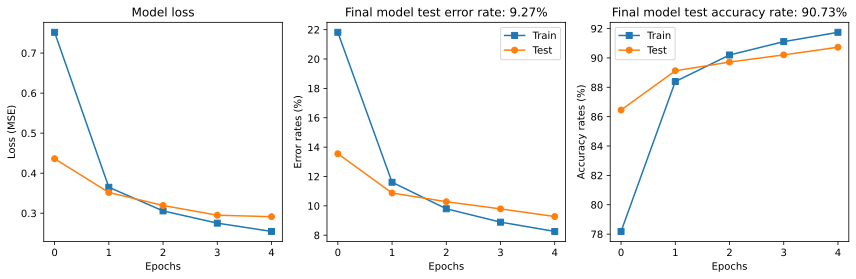

In [18]:
fig,ax = plt.subplots(1,3,figsize=(12,4))

ax[0].plot(letters_trainLoss,'s-',label='Train')
ax[0].plot(letters_testLoss,'o-',label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model loss')

ax[1].plot(letters_trainErr,'s-',label='Train')
ax[1].plot(letters_testErr,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Error rates (%)')
ax[1].set_title(f'Final model test error rate: {letters_testErr[-1]:.2f}%')
ax[1].legend()

ax[2].plot(100-letters_trainErr,'s-',label='Train')
ax[2].plot(100-letters_testErr,'o-',label='Test')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Accuracy rates (%)')
ax[2].set_title(f'Final model test accuracy rate: {100-letters_testErr[-1]:.2f}%')
ax[2].legend()

fig.tight_layout()
plt.show()

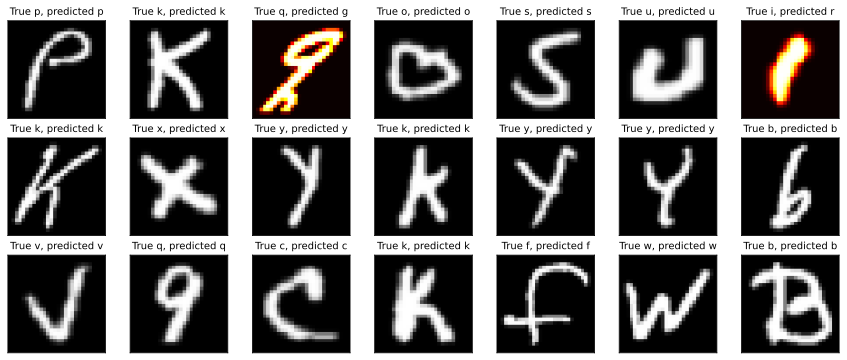

In [19]:
### visualize some images

# extract X,y from test dataloader
X,y = next(iter(letters_test_loader))
X = X.to(device) # push data to GPU
y = y.to(device) # push data to GPU
yHat = letters_net(X)

# pick some examples at random to show
randex = np.random.choice(len(y),size=21,replace=False)

# visualize some images
fig,axs = plt.subplots(3,7,figsize=(15,6))

for i,ax in enumerate(axs.flatten()):

  # extract the image and its target letter
  I = np.squeeze( X[randex[i],0,:,:] ).cpu() # .cpu() to transfer back from GPU!
  trueLetter = letterCategories[ y[randex[i]] ]
  predLetter = letterCategories[ torch.argmax(yHat[randex[i],:]) ]

  # color-code the accuracy (using ternary operator)
  col = 'gray' if trueLetter==predLetter else 'hot'

  # visualize
  ax.imshow(I.T,cmap=col)
  ax.set_title('True %s, predicted %s' %(trueLetter,predLetter),fontsize=10)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Accuracy by letter

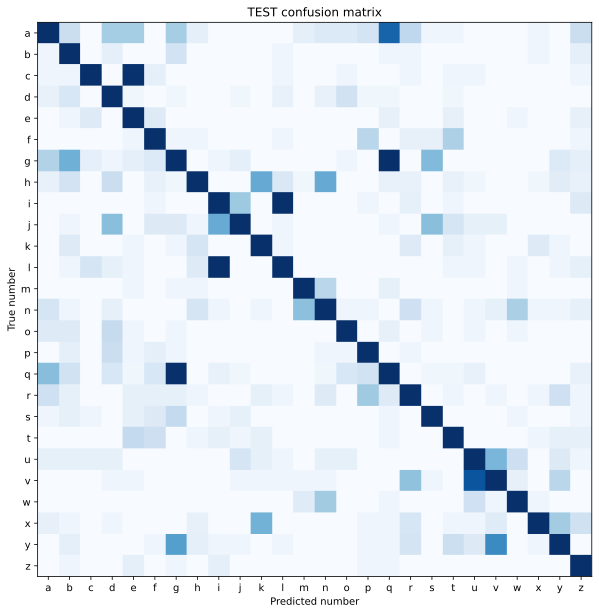

In [20]:
import sklearn.metrics as skm

# compute the confusion matrix
C = skm.confusion_matrix(y.cpu(),torch.argmax(yHat.cpu(),axis=1),normalize='true')

# visualize it
fig = plt.figure(figsize=(10,10))
plt.imshow(C,'Blues',vmax=.05)

# make the plot look nicer
plt.xticks(range(26),labels=letterCategories)
plt.yticks(range(26),labels=letterCategories)
plt.title('TEST confusion matrix')
plt.xlabel('True number')
plt.xlabel('Predicted number')
plt.ylabel('True number')

plt.show()

# Transfer model to digits

In [21]:
# Transfer model to digits (10 digit classes)
digits_net,digits_lossfun,digits_optimizer = makeTheNet(nOutputs=10)
digits_net = digits_net.to(device)

for i,layer in enumerate(['conv1','bnorm1','conv2','bnorm2','fc1']):
    letters_params = getattr(letters_net,layer).parameters()
    digits_params = getattr(digits_net,layer).parameters()
    lw,lb = iter(letters_params)
    dw,db = iter(digits_params)
    print(f'layer {layer} weights diff sum: ', (lw - dw).sum().detach().item() )
    print(f'layer {layer} weights diff sum: ', (lb - db).sum().detach().item() )
print('layer fc2 weights diff sum:',
      (letters_net.fc2.weight[0] - digits_net.fc2.weight[0] ).sum().detach().item() )

for target, source in zip(digits_net.named_parameters(),letters_net.named_parameters()):
    print(target[0], 'fc2' not in target[0])
    if 'fc2' not in target[0]:
        target[1].data = copy.deepcopy( source[1].data )
   
for i,layer in enumerate(['conv1','bnorm1','conv2','bnorm2','fc1']):
    letters_params = getattr(letters_net,layer).parameters()
    digits_params = getattr(digits_net,layer).parameters()
    lw,lb = iter(letters_params)
    dw,db = iter(digits_params)
    print(f'layer {layer} weights diff sum: ', (lw - dw).sum().detach().item() )
    print(f'layer {layer} weights diff sum: ', (lb - db).sum().detach().item() )
print('layer fc2 weights diff sum:',
      (letters_net.fc2.weight[0] - digits_net.fc2.weight[0] ).sum().detach().item() )

layer conv1 weights diff sum:  -2.027536630630493
layer conv1 weights diff sum:  -1.416059970855713
layer bnorm1 weights diff sum:  0.07013440132141113
layer bnorm1 weights diff sum:  0.9288257360458374
layer conv2 weights diff sum:  -2.7021820545196533
layer conv2 weights diff sum:  -0.03771395981311798
layer bnorm2 weights diff sum:  3.5992350578308105
layer bnorm2 weights diff sum:  2.841174602508545
layer fc1 weights diff sum:  67.26734924316406
layer fc1 weights diff sum:  0.1391623616218567
layer fc2 weights diff sum: -1.6552512645721436
conv1.weight True
conv1.bias True
bnorm1.weight True
bnorm1.bias True
conv2.weight True
conv2.bias True
bnorm2.weight True
bnorm2.bias True
fc1.weight True
fc1.bias True
fc2.weight False
fc2.bias False
layer conv1 weights diff sum:  0.0
layer conv1 weights diff sum:  0.0
layer bnorm1 weights diff sum:  0.0
layer bnorm1 weights diff sum:  0.0
layer conv2 weights diff sum:  0.0
layer conv2 weights diff sum:  0.0
layer bnorm2 weights diff sum:  0.0


Digits net accuracy without retraining: 10.23%


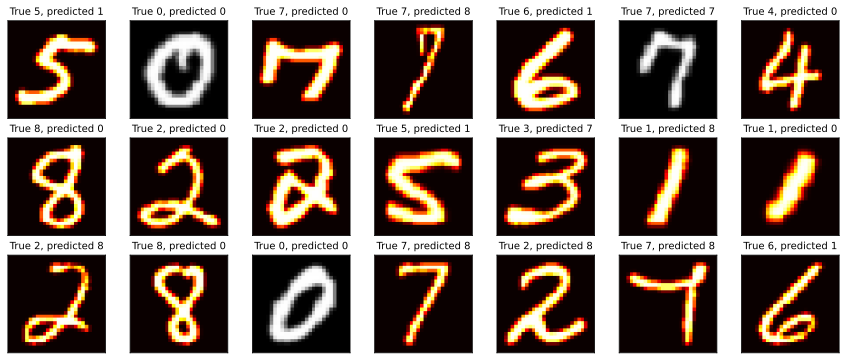

In [22]:
# Run letters model on digits test data

# extract X,y from test dataloader
X,y = next(iter(digits_test_loader))
X = X.to(device) # push data to GPU
y = y.to(device) # push data to GPU
yHat = digits_net(X)
print(f'Digits net accuracy without retraining: {100*digits_net.accuracy(yHat,y):.2f}%')

# pick some examples at random to show
randex = np.random.choice(len(y),size=21,replace=False)

# visualize some images
fig,axs = plt.subplots(3,7,figsize=(15,6))

for i,ax in enumerate(axs.flatten()):

  # extract the image and its target letter
  I = np.squeeze( X[randex[i],0,:,:] ).cpu() # .cpu() to transfer back from GPU!
  trueDigit = digitCategories[ y[randex[i]] ]
  idx = torch.argmax(yHat[randex[i]]).detach().item()
  predDigit = digitCategories[ idx ]

  # color-code the accuracy (using ternary operator)
  col = 'gray' if trueDigit==predDigit else 'hot'
  # visualize
  ax.imshow(I.T,cmap=col)
  ax.set_title('True %s, predicted %s' %(trueDigit,predDigit),fontsize=10)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

In [23]:
# Fine-tune the model on digits data over one epoch:

digits_trainLoss,digits_testLoss,digits_trainErr,digits_testErr,digits_net = \
    function2trainTheModel(digits_net,digits_lossfun,digits_optimizer,digits_train_loader,digits_test_loader,numepochs=1)

In [24]:
print(f'numberNet TRAIN accuracy: {100 - digits_trainErr[-1]:.2f}%')
print(f'numberNet TEST accuracy: {100 - digits_testErr[-1]:.2f}%')

numberNet TRAIN accuracy: 97.07%
numberNet TEST accuracy: 98.68%


In [25]:
# Create additional digits model and transfer from letters model:
digits_net,digits_lossfun,digits_optimizer = makeTheNet(nOutputs=10)
digits_net = digits_net.to(device)

for i,layer in enumerate(['conv1','bnorm1','conv2','bnorm2','fc1']):
    letters_params = getattr(letters_net,layer).parameters()
    digits_params = getattr(digits_net,layer).parameters()
    lw,lb = iter(letters_params)
    dw,db = iter(digits_params)
    print(f'layer {layer} weights diff sum: ', (lw - dw).sum().detach().item() )
    print(f'layer {layer} weights diff sum: ', (lb - db).sum().detach().item() )
print('layer fc2 weights diff sum:',
      (letters_net.fc2.weight[0] - digits_net.fc2.weight[0] ).sum().detach().item() )

for target, source in zip(digits_net.named_parameters(),letters_net.named_parameters()):
    print(target[0], 'fc2' not in target[0])
    if 'fc2' not in target[0]:
        target[1].data = copy.deepcopy( source[1].data )
   
for i,layer in enumerate(['conv1','bnorm1','conv2','bnorm2','fc1']):
    letters_params = getattr(letters_net,layer).parameters()
    digits_params = getattr(digits_net,layer).parameters()
    lw,lb = iter(letters_params)
    dw,db = iter(digits_params)
    print(f'layer {layer} weights diff sum: ', (lw - dw).sum().detach().item() )
    print(f'layer {layer} weights diff sum: ', (lb - db).sum().detach().item() )
print('layer fc2 weights diff sum:',
      (letters_net.fc2.weight[0] - digits_net.fc2.weight[0] ).sum().detach().item() )

layer conv1 weights diff sum:  -0.9003967046737671
layer conv1 weights diff sum:  0.40121766924858093
layer bnorm1 weights diff sum:  0.07013440132141113
layer bnorm1 weights diff sum:  0.9288257360458374
layer conv2 weights diff sum:  -4.1587629318237305
layer conv2 weights diff sum:  0.15313878655433655
layer bnorm2 weights diff sum:  3.5992350578308105
layer bnorm2 weights diff sum:  2.841174602508545
layer fc1 weights diff sum:  68.33103942871094
layer fc1 weights diff sum:  -0.09881673753261566
layer fc2 weights diff sum: -0.8652527332305908
conv1.weight True
conv1.bias True
bnorm1.weight True
bnorm1.bias True
conv2.weight True
conv2.bias True
bnorm2.weight True
bnorm2.bias True
fc1.weight True
fc1.bias True
fc2.weight False
fc2.bias False
layer conv1 weights diff sum:  0.0
layer conv1 weights diff sum:  0.0
layer bnorm1 weights diff sum:  0.0
layer bnorm1 weights diff sum:  0.0
layer conv2 weights diff sum:  0.0
layer conv2 weights diff sum:  0.0
layer bnorm2 weights diff sum:  0

In [26]:
# Fine-tune the model on digits data over one epoch only for categorizational layers:
digits_net.set_conv_layers_freeze(freeze=True)
digits_trainLoss,digits_testLoss,digits_trainErr,digits_testErr,digits_net = \
    function2trainTheModel(digits_net,digits_lossfun,digits_optimizer,digits_train_loader,digits_test_loader,numepochs=1)

In [27]:
print(f'numberNet TRAIN accuracy: {100 - digits_trainErr[-1]:.2f}%')
print(f'numberNet TEST accuracy: {100 - digits_testErr[-1]:.2f}%')

numberNet TRAIN accuracy: 97.05%
numberNet TEST accuracy: 98.69%


In [28]:
print('digits_net.conv_layers_status_str():', digits_net.conv_layers_status_str())

digits_net.conv_layers_status_str(): Layer 1 (conv1): weights require_grad=False, bias requires_grad=False
Layer 2 (bnorm1): weights require_grad=False, bias requires_grad=False
Layer 3 (conv2): weights require_grad=False, bias requires_grad=False
Layer 4 (bnorm2): weights require_grad=False, bias requires_grad=False
Layer 5 (fc1): weights require_grad=True, bias requires_grad=True
Layer 6 (fc2): weights require_grad=True, bias requires_grad=True

